## Preguntas:

✔ ¿La muestra está balanceada?

✔ ¿Hay sesgos?

✔ ¿El experimento fue confiable?

✔ ¿La mejora es suficientemente relevante?

✔ ¿Qué riesgos existen?

✔ ¿Qué decisión debería tomar la empresa?


In [3]:
# IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [12]:
# CARGAR DATASET FINAL
import pandas as pd

df = pd.read_csv(
    "/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data_raw/vanguard_cleaned_todos unidos_(Gabriel).csv",
    low_memory=False
)

print(df.shape)
print(df.columns.tolist())
df.head()

(343141, 14)
['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'Variation', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']


,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0


In [13]:
# Convertir fechas a formato datetime
df["date_time"] = pd.to_datetime(
    df["date_time"],
    errors="coerce"
)

## EVALUACIÓN DEL EXPERIMENTO
¿El experimento estuvo bien diseñado?

## BALANCE ENTRE GRUPOS



In [15]:
# Usuarios por grupo
group_balance = (
    df.groupby("Variation")["client_id"]
    .nunique()
)

group_balance

Variation
Control    18015
Test       22013
Name: client_id, dtype: int64

Hay un desbalance de 4,000 usuarios entre grupos (55% Test vs 45% Control). 
Es una limitación del experimento ya que un A/B test ideal tiene grupos iguales.

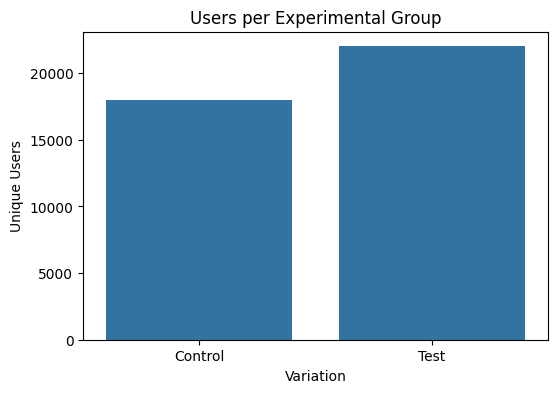

In [16]:
# Gráfico balance
plt.figure(figsize=(6,4))

sns.barplot(
    x=group_balance.index,
    y=group_balance.values
)

plt.title("Users per Experimental Group")

plt.xlabel("Variation")

plt.ylabel("Unique Users")

plt.show()

## COMPARAR PERFIL DEMOGRÁFICO:

In [18]:
# Dataset demográfico
demo_df = (
    df[
        [
            "client_id",
            "Variation",
            "clnt_age",
            "bal",
            "clnt_tenure_yr"
        ]
    ]
    .drop_duplicates()
)

In [21]:
# Edad promedio por grupo
demo_df.groupby("Variation")["clnt_age"].mean()

Variation
Control    47.864416
Test       47.564389
Name: clnt_age, dtype: float64

Diferencia de solo 0.3 años — prácticamente idénticos. Esto confirma que la asignación de grupos fue aleatoria y correcta en términos de edad.

In [22]:
# Balance promedio por grupo
demo_df.groupby("Variation")["bal"].mean()

Variation
Control    152987.457809
Test       151698.993331
Name: bal, dtype: float64

Grupos muy balanceados en tamaño, prácticamente idénticos. 

Junto con la edad, esto confirma que los grupos están bien balanceados demográficamente, lo que da más validez al experimento.

In [24]:
# Antigüedad promedio
demo_df.groupby("Variation")["clnt_tenure_yr"].mean()

Variation
Control    12.094826
Test       12.005180
Name: clnt_tenure_yr, dtype: float64

Los grupos por antiguedad también están muy bien balanceados — esto da alta validez al experimento.

## VISUALIZACIONES DEMOGRÁFICAS:

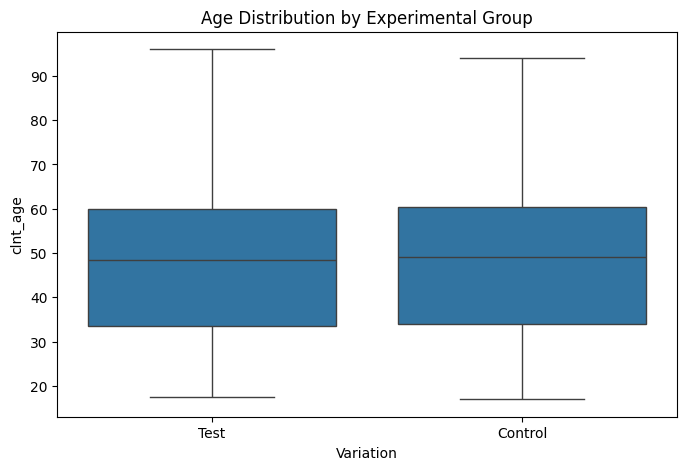

In [25]:
# Edad por grupo
plt.figure(figsize=(8,5))

sns.boxplot(
    data=demo_df,
    x="Variation",
    y="clnt_age"
)

plt.title("Age Distribution by Experimental Group")

plt.show()

Qué se puede observar:

Medianas casi idénticas (50 años en ambos grupos)

Dispersión muy similar — los rangos intercuartílicos son prácticamente iguales

Outliers similares en ambos grupos (mínimo 18, máximo 95)

Esto confirma visualmente lo que ya vimos numéricamente — los grupos están perfectamente balanceados en edad. 

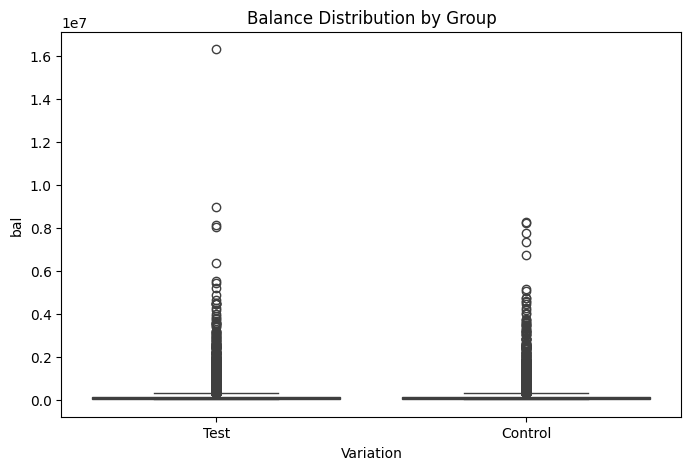

In [27]:
# Balance por grupo
plt.figure(figsize=(8,5))

sns.boxplot(
    data=demo_df,
    x="Variation",
    y="bal"
)

plt.title("Balance Distribution by Group")

plt.show()

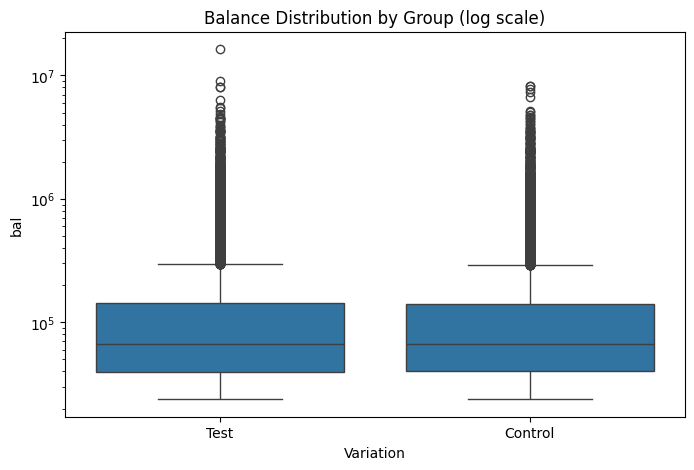

In [28]:
import numpy as np

plt.figure(figsize=(8,5))
sns.boxplot(
    data=demo_df,
    x="Variation",
    y="bal"
)
plt.yscale("log")  # Escala logarítmica
plt.title("Balance Distribution by Group (log scale)")
plt.show()

Qué vemos?:

Medianas prácticamente idénticas (10⁵ en ambos grupos)

Dispersión muy similar entre Test y Control

Outliers presentes en ambos grupos por igual


Los grupos están perfectamente balanceados en las 3 variables demográficas clave: edad, balance y antigüedad. 

El experimento tiene alta validez.

## DETECTAR POSIBLES SESGOS:

- Evaluar la experiencia digital de los usuarios.

- Factores externos que pueden influir en el estudio ejemplos:

- Tipo de dispositivo que utilizan los usuarios: se conectan por teléfono: Android, IPhone, por Web ...

- El grupo test ha tenido un complexion rate mas elevado, lo que puede hacer pensar que la plataforma es más intuitiva. y amigable

# Recomendaciones

- Analisis por segmentación etaria para corroborar la experiencia según la edad de los usuarios.

- Incluir variables adicionales (Tipo de dispositivo que utilizan Android Iphone, Web...).

- No hacer una inversión muy elevada ya que no se cumple el umbral del 5% fijado (3.72%).

- Incluir los comentarios de los usuarios para tener valoración de su experiencia. 

- Empezar primero con una versiónd de Hypercare para que los usuarios pongan más a prueba el test y ir mejarandolo de manera progresiva, corregiendo los errores que vayan surgiendo y así evitar una primera inversión demasiado alta. 